<a href="https://colab.research.google.com/github/agus-beep952/Estadisticaverano2026/blob/main/Unidad4/Proyecto_U4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df= pd.read_csv("https://raw.githubusercontent.com/lauraaguilargonzalez18/estadisticaverano2026/refs/heads/main/insurance.csv")
df

,edad,sexo,IMC,niños,fumador,región,gastos
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


In [ ]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/lauraaguilargonzalez18/estadisticaverano2026/refs/heads/main/insurance.csv")
df.columns

Index(['edad', 'sexo', 'IMC', 'niños', 'fumador', 'región', 'gastos'], dtype='object')

In [ ]:
# Estadísticos descriptivos por fumador2df.groupby('fumador')['gastos'].describe()3 4# Estadísticos descriptivos por sexo5df.groupby('sexo')['gastos'].describe()6 7# Estadísticos descriptivos por región8df.groupby('región')['gastos'].describe()
df

,edad,sexo,IMC,niños,fumador,región,gastos
0,19,2,27.9,0,2,4,16884.92
1,18,1,33.8,1,1,3,1725.55
2,28,1,33.0,3,1,3,4449.46
3,33,1,22.7,0,1,2,21984.47
4,32,1,28.9,0,1,2,3866.86
...,...,...,...,...,...,...,...
1333,50,1,31.0,3,1,2,10600.55
1334,18,2,31.9,0,1,1,2205.98
1335,18,2,36.9,0,1,3,1629.83
1336,21,2,25.8,0,1,4,2007.95


**Se observa que el promedio de gastos médicos es diferente entre fumadores y no fumadores. Esto sugiere que el hábito de fumar podría estar relacionado con mayores gastos médicos.**

# EDAD

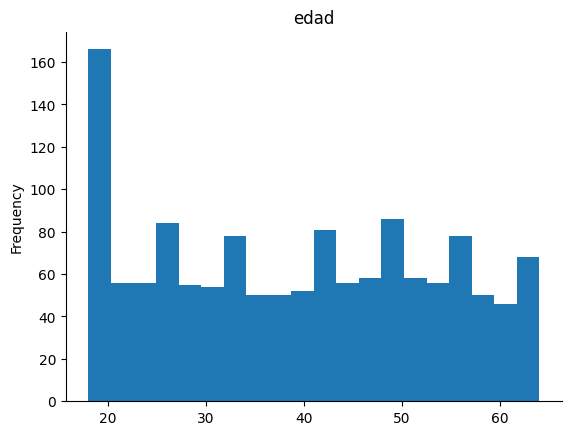

In [ ]:
from matplotlib import pyplot as plt
df['edad'].plot(kind='hist', bins=20, title='edad')
plt.gca().spines[['top','right',]].set_visible(False)


# SEXO

In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm # Importamos la función anova_lm
modelo_lineal=ols("gastos ~ C(sexo)", data=df).fit()
tabla_anova=anova_lm(modelo_lineal) # Llamamos directamente a la función anova_lm
# print("Ho: No hay relacion entre X y Y")
#else:
 # print("H1: Si hay relacion entre X y Y")
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
C(sexo),1.0,6.435904e+08,6.435904e+08,4.399703,0.036133
Residual,1336.0,1.954306e+11,1.462804e+08,NaN,NaN


  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2  meandiff p-adj   lower    upper   reject
-------------------------------------------------------
female   male 1387.1725 0.0361 89.8125 2684.5326   True
-------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

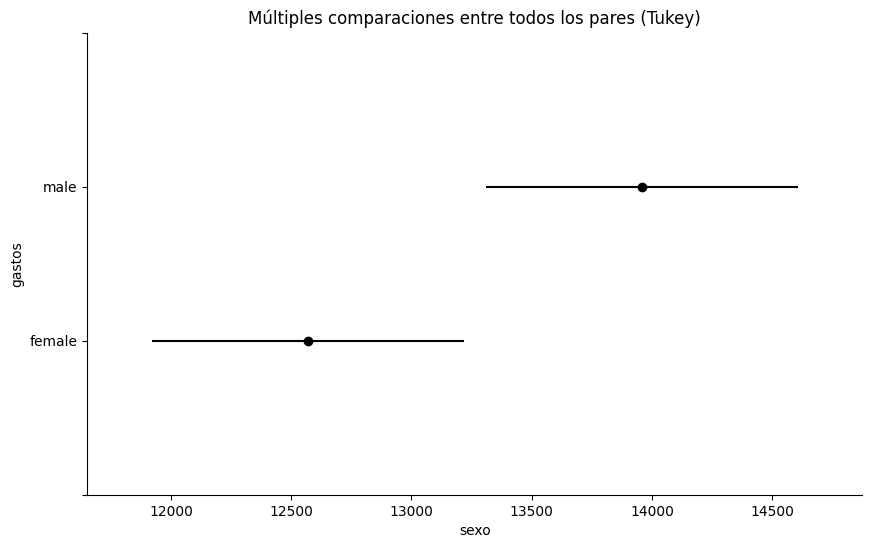

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['gastos'], # Variable de respuesta
    groups=df['sexo'],  # tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="gastos", xlabel="sexo")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
df ['sexo']=df['sexo'].map({'male':1, 'female':2})
df

,edad,sexo,IMC,niños,fumador,región,gastos
0,19,2,27.9,0,yes,southwest,16884.92
1,18,1,33.8,1,no,southeast,1725.55
2,28,1,33.0,3,no,southeast,4449.46
3,33,1,22.7,0,no,northwest,21984.47
4,32,1,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,1,31.0,3,no,northwest,10600.55
1334,18,2,31.9,0,no,northeast,2205.98
1335,18,2,36.9,0,no,southeast,1629.83
1336,21,2,25.8,0,no,southwest,2007.95


# IMC

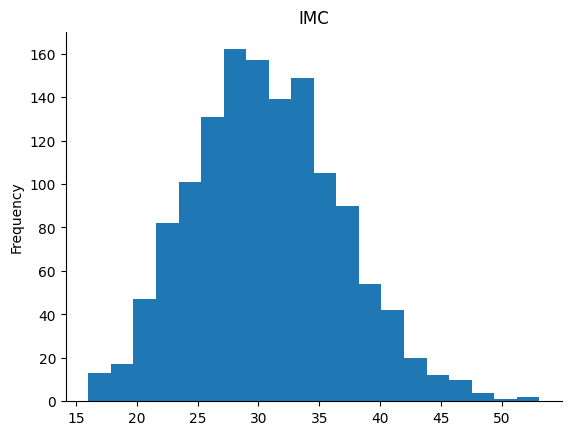

In [ ]:
#IMC
from matplotlib import pyplot as plt
df['IMC'].plot(kind='hist', bins=20, title='IMC')
plt.gca().spines[['top','right',]].set_visible(False)


# NIÑOS

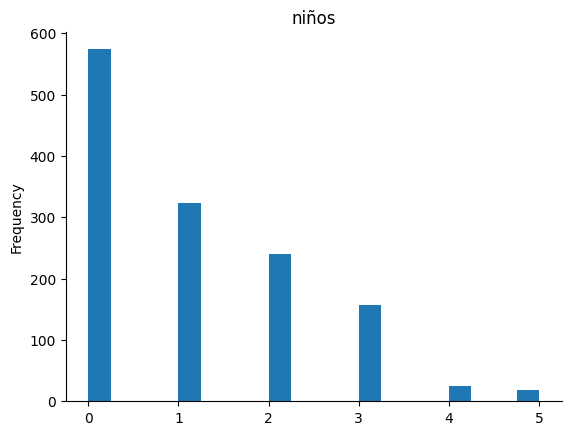

In [ ]:
from matplotlib import pyplot as plt
df['niños'].plot(kind='hist', bins=20, title='niños')
plt.gca().spines[['top','right',]].set_visible(False)

# FUMADORES

In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm # Importamos la función anova_lm
modelo_lineal=ols("gastos ~ C(fumador)", data=df).fit()
tabla_anova=anova_lm(modelo_lineal) # Llamamos directamente a la función anova_lm
# print("Ho: No hay relacion entre X y Y")
#else:
 # print("H1: Si hay relacion entre X y Y")
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
C(fumador),1.0,1.215199e+11,1.215199e+11,2177.614859,8.271450e-283
Residual,1336.0,7.455432e+10,5.580413e+07,NaN,NaN


    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
group1 group2  meandiff  p-adj   lower      upper    reject
-----------------------------------------------------------
    no    yes 23615.9635   0.0 22623.1748 24608.7523   True
-----------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

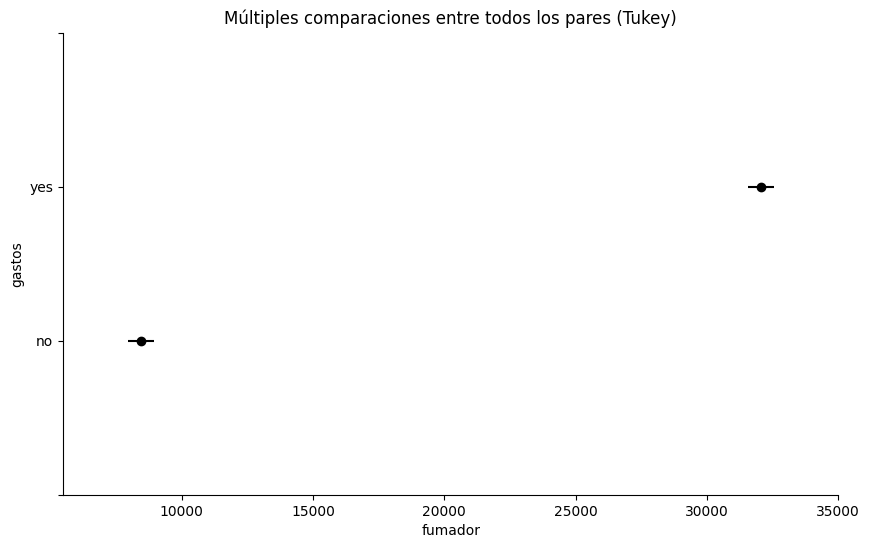

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['gastos'], # Variable de respuesta
    groups=df['fumador'],  # tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="gastos", xlabel="fumador")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
df ['fumador']=df['fumador'].map({'no':1, 'yes':2})
df

,edad,sexo,IMC,niños,fumador,región,gastos
0,19,2,27.9,0,2,southwest,16884.92
1,18,1,33.8,1,1,southeast,1725.55
2,28,1,33.0,3,1,southeast,4449.46
3,33,1,22.7,0,1,northwest,21984.47
4,32,1,28.9,0,1,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,1,31.0,3,1,northwest,10600.55
1334,18,2,31.9,0,1,northeast,2205.98
1335,18,2,36.9,0,1,southeast,1629.83
1336,21,2,25.8,0,1,southwest,2007.95


# **REGION**

In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
modelo_lineal=ols("gastos ~ C(región)", data=df).fit() # Corregido 'region' a 'región'
tabla_anova=sm.stats.anova_lm(modelo_lineal)
# Llamamos directamente a la función anova_lm
#("H0: No hay relacion entre X y Y")
#("H1: Si hay relacion entre X y Y")
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
C(región),3.0,1.300760e+09,4.335865e+08,2.969627,0.030893
Residual,1334.0,1.947735e+11,1.460071e+08,NaN,NaN


       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
  group1    group2   meandiff  p-adj    lower      upper   reject
-----------------------------------------------------------------
northeast northwest  -988.8095 0.7245 -3428.9347 1451.3157  False
northeast southeast  1329.0268 0.4745 -1044.9417 3702.9954  False
northeast southwest -1059.4468 0.6792  -3499.572 1380.6784  False
northwest southeast  2317.8364 0.0583   -54.1991 4689.8719  False
northwest southwest   -70.6373 0.9999 -2508.8818 2367.6073  False
southeast southwest -2388.4736 0.0477 -4760.5091  -16.4381   True
-----------------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

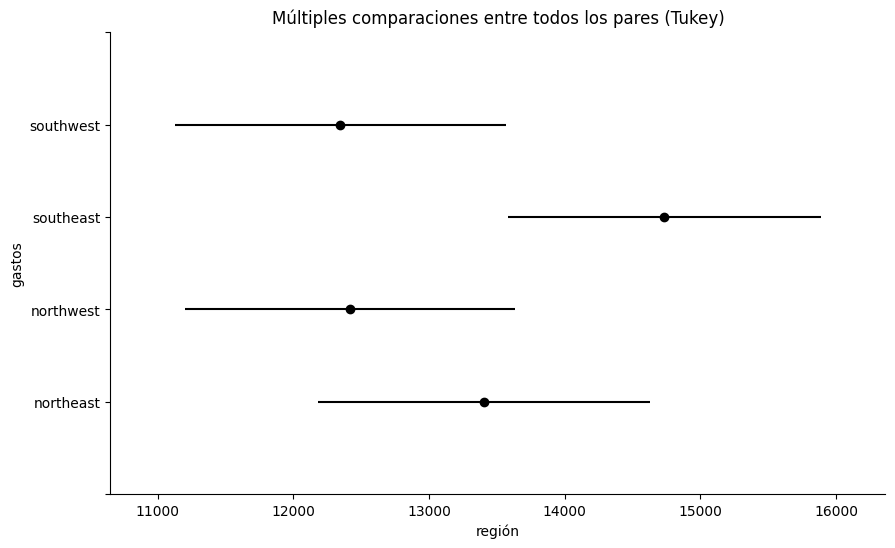

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['gastos'], # Variable de respuesta
    groups=df['región'],  # tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="gastos", xlabel="región")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
df ['región'] = df['región'].map({'northeast':1, 'northwest':2, 'southeast':3, 'southwest':4})
df

,edad,sexo,IMC,niños,fumador,región,gastos
0,19,2,27.9,0,2,4,16884.92
1,18,1,33.8,1,1,3,1725.55
2,28,1,33.0,3,1,3,4449.46
3,33,1,22.7,0,1,2,21984.47
4,32,1,28.9,0,1,2,3866.86
...,...,...,...,...,...,...,...
1333,50,1,31.0,3,1,2,10600.55
1334,18,2,31.9,0,1,1,2205.98
1335,18,2,36.9,0,1,3,1629.83
1336,21,2,25.8,0,1,4,2007.95


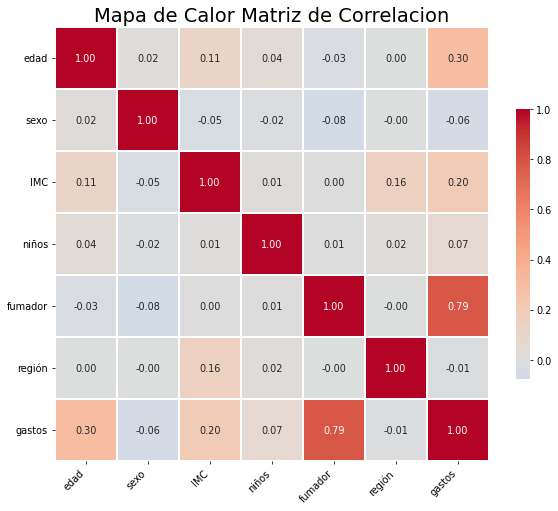

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
matriz_de_correlacion = df.corr()
plt.figure(figsize=(10,10),dpi=70)
sns.heatmap(matriz_de_correlacion, #lo que va a grafica
    annot=True,#se muestran los valores en las celdas
    fmt="0.2f", #0.2f significa 2 decimales
    cmap="coolwarm", #paleta de colroes
    square=True,#forzar cuadrado
    linewidths=0.5,#grosor de lineas
    cbar_kws={"shrink":0.5}, #tama;o de barra lateral
    center=0, #linea vertical central
)
plt.title("Mapa de Calor Matriz de Correlacion",fontsize=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()


In [ ]:
x=df["fumador"]
y=["gastos"]
df.head(10)
print(df)
print("/n")

      edad  sexo   IMC  niños  fumador  región    gastos
0       19     2  27.9      0        2       4  16884.92
1       18     1  33.8      1        1       3   1725.55
2       28     1  33.0      3        1       3   4449.46
3       33     1  22.7      0        1       2  21984.47
4       32     1  28.9      0        1       2   3866.86
...    ...   ...   ...    ...      ...     ...       ...
1333    50     1  31.0      3        1       2  10600.55
1334    18     2  31.9      0        1       1   2205.98
1335    18     2  36.9      0        1       3   1629.83
1336    21     2  25.8      0        1       4   2007.95
1337    61     2  29.1      0        2       2  29141.36

[1338 rows x 7 columns]
/n


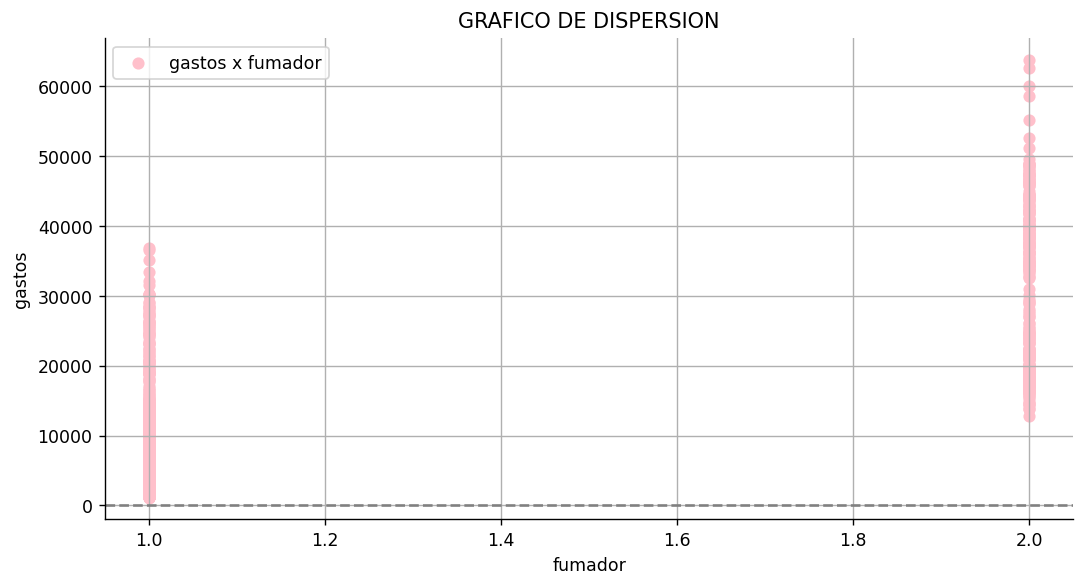

In [ ]:
#REALIZAR UN DIAGRAMA DE DISPERSION PARA LOS DATOS
import matplotlib.pyplot as plt

# Corregir la definición de y
y = df["gastos"]

plt.figure(figsize=(10,5),dpi=125)
plt.scatter (x, y,
            label="gastos x fumador",
            color="pink")
plt.title("GRAFICO DE DISPERSION")
plt.xlabel("fumador")
plt.ylabel("gastos")
plt.axhline(y=0, color="GREY", linestyle="--")
plt.legend()
plt.grid()
df.head()
plt.gca().spines[["top","right"]].set_visible(False)

In [ ]:
from scipy.stats import pearsonr
r,_=pearsonr(x,y)
print( f"COEFICIENTE DE CORRELACION: {r: 0.4f}\n")

COEFICIENTE DE CORRELACION:  0.7873



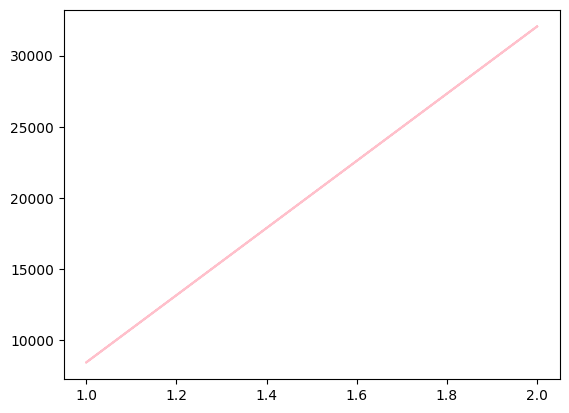

In [ ]:
import statsmodels.api as sm
x_constante=sm.add_constant(x)
modelo=sm.OLS(y,x_constante).fit()
yc=modelo.predict(x_constante)
plt.plot(x,yc, color="pink")

In [ ]:
from sklearn.metrics import r2_score
r2=r2_score(y,yc)
print( f"COEFICIENTE DE DETERMINACION: {r2: 0.4f} \n")

COEFICIENTE DE DETERMINACION:  0.6198 



In [ ]:
nivel_confianza= 0.95
intervalo_de_confianza=modelo.conf_int(alpha= 1 - nivel_confianza)
intervalo_de_confianza_b1=intervalo_de_confianza.iloc[1]
print(f"INTERVALO DE CONFIANZA DEL PARA b1 ES: {nivel_confianza:0.0%} \n")
print(f"{intervalo_de_confianza_b1[0]: 0.4f} < b1 < {intervalo_de_confianza_b1[1]: 0.4f} \n")


INTERVALO DE CONFIANZA DEL PARA b1 ES: 95% 

 22623.1748 < b1 <  24608.7523 



In [ ]:
residuales = modelo.resid

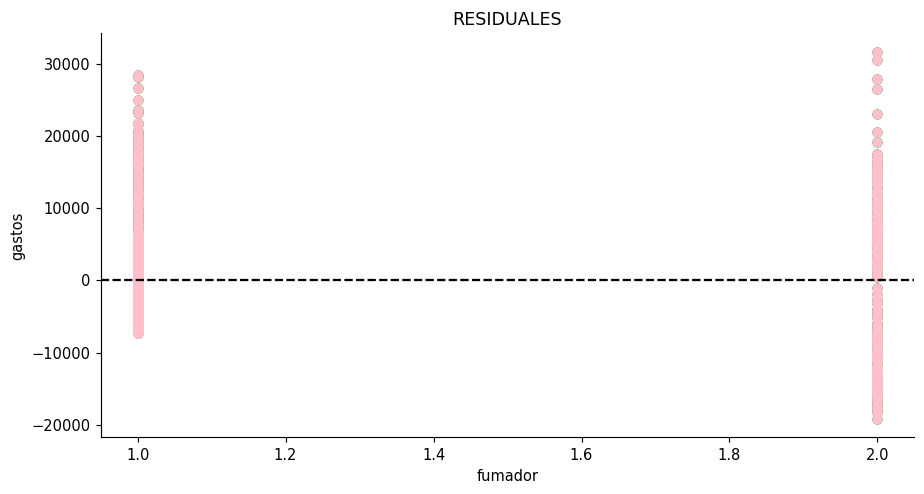

In [ ]:
plt.figure(figsize=(10,5),dpi=105)
plt.scatter(x,residuales, color="Green")
plt.title("RESIDUALES")
plt.xlabel("fumador")
plt.ylabel("gastos")
plt.axhline(y=0, color="grey", linestyle="--")
plt.scatter(x, residuales,
            label="Fumador",
            color="pink")
plt.axhline(y=0, color="BLACK", linestyle="--")
plt.gca().spines[["top","right"]].set_visible(False)

In [ ]:
from scipy.stats import shapiro
estadistico_shapiro, valor_p_sh = shapiro(residuales)
print("valor_p_sh:", valor_p_sh )
print("\n")
if valor_p_sh<0.05:
  print("Los datos no siguen una distribucion normal")
else:
  print("Los datos siguen una distribucion normal \n")

valor_p_sh: 1.6718566049034953e-18


Los datos no siguen una distribucion normal


valor-p (Shapiro) = 1.6718566049034953e-18


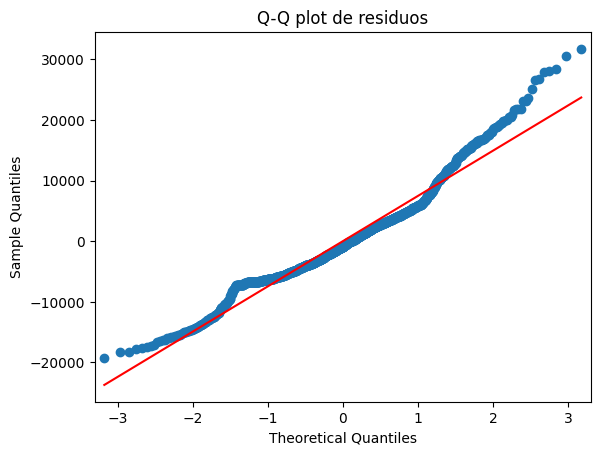

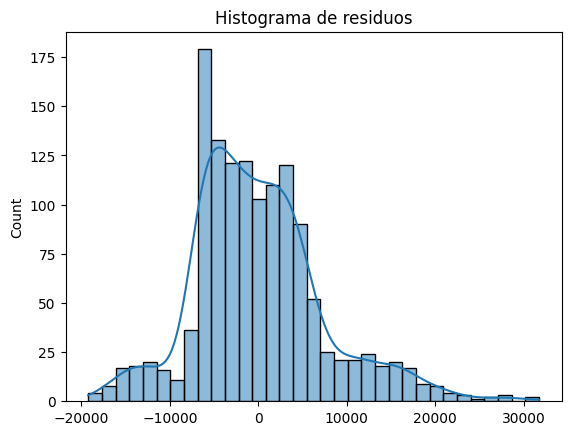

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print("valor_p_bp:", valor_p_bp)
print("\n")
if valor_p_bp<0.05:
  print("Hay heteroscedasticidad")
else:
  print("Hay homosedasticidad \n")


valor_p_bp: 2.82672985018033e-45


Hay heteroscedasticidad


In [ ]:
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('gastos ~ fumador + edad', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
fumador,1.0,1.215199e+11,1.215199e+11,2969.807878,0.000000e+00
edad,1.0,1.992820e+10,1.992820e+10,487.022526,2.909757e-92
Residual,1335.0,5.462612e+10,4.091844e+07,NaN,NaN


In [ ]:
x = df[["fumador", "edad", "IMC"]]
y = df["gastos"]

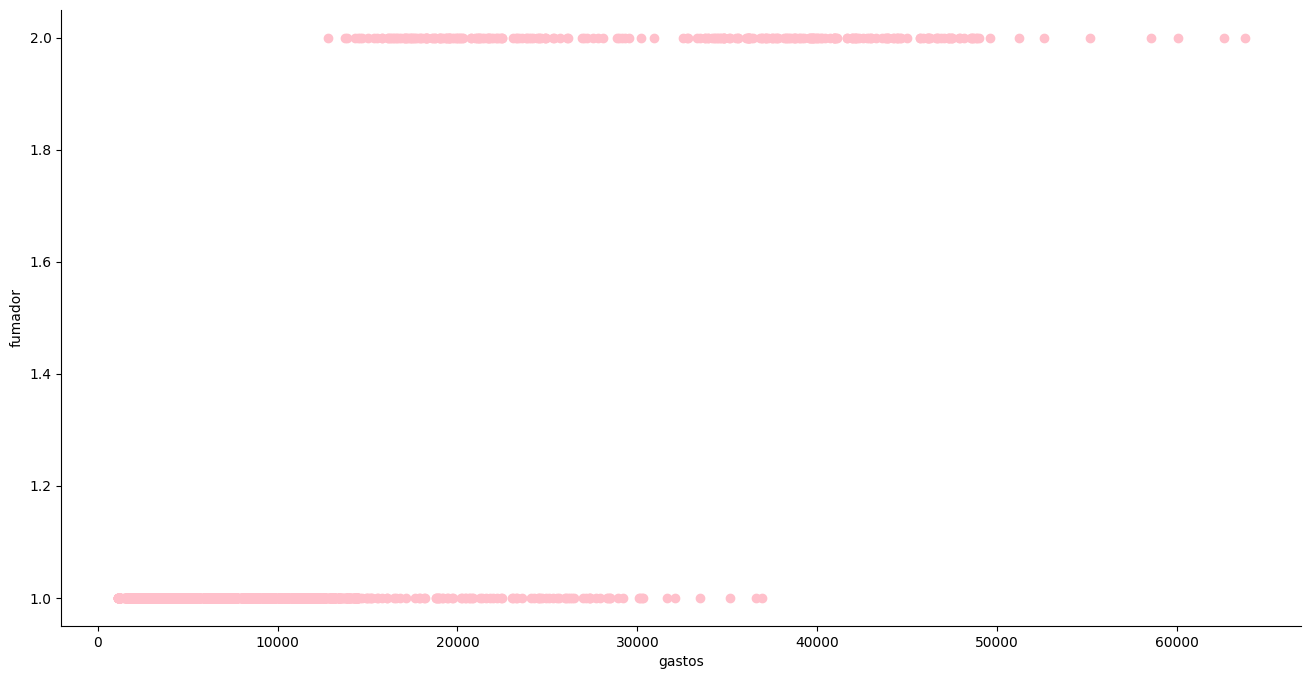

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize = (16, 8), dpi = 100)
plt.scatter(y, x['fumador'], label = "gastos", color = 'pink') # Corrected: plot y on x-axis, x['fumador'] on y-axis
plt.xlabel('gastos') # nombrar eje x
plt.ylabel('fumador') # nombrar eje y
plt.gca().spines[["top","right"]].set_visible(False)

In [ ]:
from scipy.stats import pearsonr
r, _ = pearsonr(x['fumador'], y)
print(f'Coeficiente de correlación: {r: 0.4f}\n')

Coeficiente de correlación:  0.7873



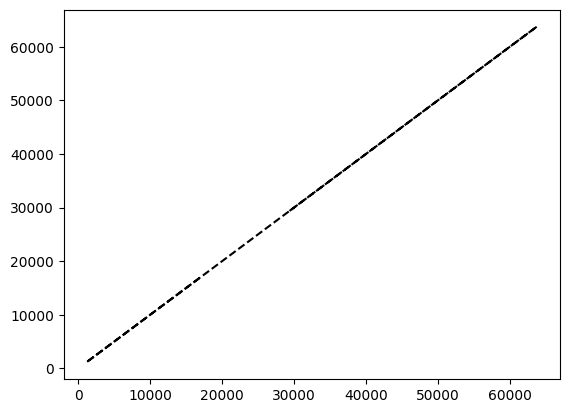

In [ ]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()

yc = modelo.predict(x_constante)
plt.figure()
plt.plot(y, y, color = 'black', linestyle = '--')

In [ ]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, yc)
print(f'Coeficiente de determinación: {r2: 0.4f}\n')


Coeficiente de determinación:  0.7475



In [ ]:
nivel_de_confianza = 0.95
intervalo_de_confianza = modelo.conf_int(alpha = 1 - nivel_de_confianza)
intervalo_de_confianza_b1 = intervalo_de_confianza.iloc[1]
print(f'Intervalo de confianza para b1 de {nivel_de_confianza: 0.0%}')
print(f'{intervalo_de_confianza_b1[0]: 0.4f} < b1 < {intervalo_de_confianza_b1[1]: 0.4f}\n')

Intervalo de confianza para b1 de  95%
 23012.6878 < b1 <  24632.5242



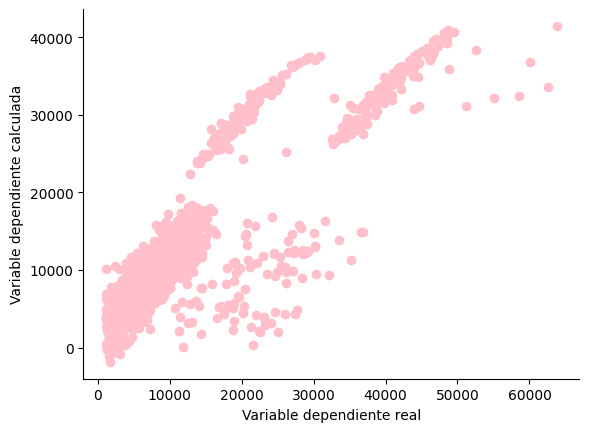

In [ ]:
residuales = modelo.resid
plt.scatter(y, yc, color = 'pink')
plt.xlabel('Variable dependiente real')
plt.ylabel('Variable dependiente calculada')
plt.gca().spines[['top', 'right']].set_visible(False)


In [ ]:
from scipy.stats import shapiro
_, valor_p_sh = shapiro(residuales)
print(f'valor-p de Shapiro: {valor_p_sh: 0.4f}\n')


valor-p de Shapiro:  0.0000



In [ ]:
from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.0000



In [ ]:
print(f'para x1 = 0.5, x2 =3, x3=34, y = {modelo.predict([1, 0.5, 3, 34])}')
print(f'para x1 = 1.5, x2 =2, x3=50, y = {modelo.predict([1, 1.5, 2, 50])}')
print(f'para x1 = 2.5, x2 =4, x3=40, y = {modelo.predict([1, 2.0, 4, 40])}\n')
# Corrected: Provide an array with 4 values (constant, fumador, edad, IMC)
print(f'Predicción con constant=1, fumador=1, edad=30, IMC=25: {modelo.get_prediction([1, 1, 30, 25]).summary_frame()}')

para x1 = 0.5, x2 =3, x3=34, y = [-11840.24266483]
para x1 = 1.5, x2 =2, x3=50, y = [16885.89329972]
para x1 = 2.5, x2 =4, x3=40, y = [26089.34785661]

Predicción con constant=1, fumador=1, edad=30, IMC=25:           mean    mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  4174.226414  260.30849    3663.567825    4684.885003  -7787.928745   

   obs_ci_upper  
0  16136.381572  


In [ ]:
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('gastos ~ fumador + edad + IMC', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
fumador,1.0,1.215199e+11,1.215199e+11,3274.201076,0.000000e+00
edad,1.0,1.992820e+10,1.992820e+10,536.940349,4.212127e-100
IMC,1.0,5.115550e+09,5.115550e+09,137.832056,2.333050e-30
Residual,1334.0,4.951057e+10,3.711437e+07,NaN,NaN
